In [1]:
"""
# Visual Python: Data Analysis > Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
%matplotlib inline
#import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
"""

'\n# Visual Python: Data Analysis > Import\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\nfrom sklearn.preprocessing import StandardScaler\n%matplotlib inline\n#import seaborn as sns\nimport warnings\nwarnings.filterwarnings("ignore")\n'

In [2]:
"""
# Visual Python: Data Analysis > Import
from sklearn.model_selection import train_test_split
from sklearn import metrics
"""

'\n# Visual Python: Data Analysis > Import\nfrom sklearn.model_selection import train_test_split\nfrom sklearn import metrics\n'

In [3]:
"""
# Visual Python: Data Analysis > File
df = pd.read_csv('creditcard.csv')
df
"""

"\n# Visual Python: Data Analysis > File\ndf = pd.read_csv('creditcard.csv')\ndf\n"

In [4]:
"""
# A look at the shape of the data
original_rows = len(df)
df.shape
"""

'\n# A look at the shape of the data\noriginal_rows = len(df)\ndf.shape\n'

In [5]:
"""
# Removing duplicate values 
df.drop_duplicates(subset = None, keep = "first", inplace = True, ignore_index = True)
"""

'\n# Removing duplicate values \ndf.drop_duplicates(subset = None, keep = "first", inplace = True, ignore_index = True)\n'

In [6]:
"""
# Again having a look at the shape of the data to check the number of removed rows
dedup_rows = len(df)
df.shape
"""

'\n# Again having a look at the shape of the data to check the number of removed rows\ndedup_rows = len(df)\ndf.shape\n'

In [7]:
%%time
import pandas as pd  # For handling datasets
from Crypto.PublicKey import RSA  # For RSA key generation
from Crypto.Cipher import AES, PKCS1_OAEP  # For encryption and decryption (RSA and AES)
from Crypto.Random import get_random_bytes  # For generating random bytes (AES key)
import base64  # For encoding binary data into strings for DataFrame storage

# Step 1: Key Generation

def generate_isogeny_keypair():
    """
    Generates an RSA keypair (private and public keys).

    Returns:
        private_key: The RSA private key (used for decryption).
        public_key: The RSA public key (used for encryption).
    """
    private_key = RSA.generate(2048)  # Generate a 2048-bit RSA private key
    public_key = private_key.publickey()  # Extract the corresponding public key
    return private_key, public_key

# Step 2: Encrypt the entire dataset

def encrypt_dataset(public_key, dataset):
    """
    Encrypts an entire dataset using a hybrid encryption approach:
    1. AES is used to encrypt the dataset.
    2. The AES key is encrypted using RSA.

    Args:
        public_key: RSA public key used to encrypt the AES key.
        dataset: The dataset (Pandas DataFrame) to encrypt.

    Returns:
        A DataFrame containing encrypted data:
            - Encrypted AES key (using RSA).
            - Nonce (used for AES encryption).
            - Ciphertext (encrypted dataset).
            - Tag (used to verify AES decryption).
    """
    # Convert the dataset into a single string for encryption
    dataset_string = '\n'.join(','.join(map(str, row.values)) for _, row in dataset.iterrows())

    # Encrypt the AES key using RSA
    cipher_rsa = PKCS1_OAEP.new(public_key)  # Initialize RSA encryption with OAEP padding
    key = get_random_bytes(16)  # Generate a random 16-byte AES key
    encrypted_key = cipher_rsa.encrypt(key)  # Encrypt the AES key with RSA

    # Encrypt the dataset using AES
    cipher_aes = AES.new(key, AES.MODE_GCM)  # Initialize AES encryption in GCM mode
    ciphertext, tag = cipher_aes.encrypt_and_digest(dataset_string.encode())  # Encrypt dataset and get tag
    nonce = cipher_aes.nonce  # Get the nonce generated by AES

    # Store encrypted data in a DataFrame for structured storage
    encrypted_data_df = pd.DataFrame({
        "encrypted_key": [base64.b64encode(encrypted_key).decode()],  # Encode encrypted key to Base64
        "nonce": [base64.b64encode(nonce).decode()],  # Encode nonce to Base64
        "ciphertext": [base64.b64encode(ciphertext).decode()],  # Encode ciphertext to Base64
        "tag": [base64.b64encode(tag).decode()]  # Encode tag to Base64
    })

    return encrypted_data_df

# Step 3: Decrypt the entire dataset

def decrypt_dataset(private_key, encrypted_data_df):
    """
    Decrypts an encrypted dataset using a hybrid decryption approach:
    1. The AES key is decrypted using RSA.
    2. The dataset is decrypted using the AES key.

    Args:
        private_key: RSA private key used to decrypt the AES key.
        encrypted_data_df: DataFrame containing encrypted data (from `encrypt_dataset`).

    Returns:
        A list of lists representing the decrypted dataset (rows and columns).
    """
    # Extract Base64-encoded encrypted data from the DataFrame and decode
    encrypted_key = base64.b64decode(encrypted_data_df["encrypted_key"].iloc[0])
    nonce = base64.b64decode(encrypted_data_df["nonce"].iloc[0])
    ciphertext = base64.b64decode(encrypted_data_df["ciphertext"].iloc[0])
    tag = base64.b64decode(encrypted_data_df["tag"].iloc[0])

    # Decrypt the AES key using RSA
    cipher_rsa = PKCS1_OAEP.new(private_key)  # Initialize RSA decryption with OAEP padding
    decrypted_key = cipher_rsa.decrypt(encrypted_key)  # Decrypt the AES key

    # Decrypt the dataset using AES
    cipher_aes = AES.new(decrypted_key, AES.MODE_GCM, nonce=nonce)  # Initialize AES decryption with nonce
    decrypted_dataset = cipher_aes.decrypt_and_verify(ciphertext, tag).decode()  # Decrypt and verify tag

    # Convert the decrypted string back to rows and columns
    return [
        row.split(',') for row in decrypted_dataset.split('\n')  # Split rows by newline and columns by comma
    ]

# Main execution

# Generate RSA keypair
private_key, public_key = generate_isogeny_keypair()

# Load the dataset (replace with the path to your actual dataset)
df2 = pd.read_csv("elliptic_txs_features.csv")  # Dataset should be in CSV format
df = df2.sample(frac=0.12, random_state=42)
# Encrypt the dataset
encrypted_data_df = encrypt_dataset(public_key, df)

# Decrypt the dataset
decrypted_rows = decrypt_dataset(private_key, encrypted_data_df)

# Convert the decrypted rows back into a DataFrame for easier comparison
# Note: Column names must match the original DataFrame

decrypted_df = pd.DataFrame(decrypted_rows, columns=df.columns)

# Print the encrypted DataFrame (contains Base64-encoded strings)
print("Encrypted DataFrame:")
print(encrypted_data_df)

# Print the decrypted DataFrame (should match the original dataset)
print("\nDecrypted DataFrame:")
print(decrypted_df)


Encrypted DataFrame:
                                       encrypted_key  \
0  mV9I9z9UvlQyzbhpzVF+w3LCHWvfiLyuyRVtI1W87/HDNP...   

                      nonce  \
0  FaLI9Y1hvM9gMz75/hOWHQ==   

                                          ciphertext                       tag  
0  t/gwgtrPMWERmCIsd5vuMHRp4r5VKAm8AwHpx+JNtT4D7F...  +zu7vBH7EAVCcGwUksAAFQ==  

Decrypted DataFrame:
         230425980     1  -0.1714692896288031 -0.18466755143291433  \
0      272481041.0  24.0  -0.1541684377243277  -0.1070124680124244   
1      331556016.0  23.0  -0.0637613883818002  -0.1587825236260844   
2       29913073.0  37.0  -0.0303507626427091     0.13889529615246   
3      209062970.0  20.0  -0.1729820388445788  -0.1755068400920772   
4       97388854.0  40.0   -0.160374432313531   0.0728625902172368   
...            ...   ...                  ...                  ...   
24447  391078225.0  17.0  -0.0825664528975555   -0.158989603848539   
24448   94365841.0   7.0  -0.1689746489856321  -0.081127440

In [8]:
import unittest
import pandas as pd
from Crypto.PublicKey import RSA
from Crypto.Cipher import AES, PKCS1_OAEP
from Crypto.Random import get_random_bytes
import base64


class TestEncryptionDecryption(unittest.TestCase):

    def setUp(self):
        # Generate RSA key pair
        self.private_key, self.public_key = generate_isogeny_keypair()

        # Create a sample dataset
        self.sample_data = {
            'Column1': [1, 2, 3],
            'Column2': ['A', 'B', 'C'],
            'Column3': [4.5, 5.5, 6.5]
        }
        self.dataset = pd.DataFrame(self.sample_data)

    def test_key_generation(self):
        # Test if key generation returns a valid RSA key pair
        self.assertIsNotNone(self.private_key)
        self.assertIsNotNone(self.public_key)
        self.assertEqual(self.private_key.size_in_bits(), 2048)
        print("Test passed: Key generation returns a valid RSA key pair.")

    def test_encrypt_dataset(self):
        # Test if the encryption process returns a valid DataFrame
        encrypted_df = encrypt_dataset(self.public_key, self.dataset)
        self.assertIsInstance(encrypted_df, pd.DataFrame)
        self.assertIn('encrypted_key', encrypted_df.columns)
        self.assertIn('nonce', encrypted_df.columns)
        self.assertIn('ciphertext', encrypted_df.columns)
        self.assertIn('tag', encrypted_df.columns)
        print("Test passed: Encryption process returns a valid DataFrame with the expected columns.")

    def test_decrypt_dataset(self):
        # Encrypt the dataset
        encrypted_df = encrypt_dataset(self.public_key, self.dataset)
    
        # Decrypt the dataset
        decrypted_rows = decrypt_dataset(self.private_key, encrypted_df)
    
        # Convert decrypted rows back into a DataFrame
        decrypted_df = pd.DataFrame(decrypted_rows, columns=self.dataset.columns)
    
        # Convert columns of the decrypted DataFrame back to the original data types
        for column in self.dataset.columns:
            decrypted_df[column] = decrypted_df[column].astype(self.dataset[column].dtype)
    
        # Compare the original and decrypted datasets
        pd.testing.assert_frame_equal(self.dataset, decrypted_df, check_dtype=False)
        print("Test passed: Decryption correctly restores the original dataset.")

    def test_invalid_decryption(self):
        # Test decryption with a mismatched private key
        other_private_key, _ = generate_isogeny_keypair()
        encrypted_df = encrypt_dataset(self.public_key, self.dataset)

        with self.assertRaises(ValueError):
            decrypt_dataset(other_private_key, encrypted_df)
        print("Test passed: Invalid decryption raises ValueError as expected.")

def run_tests():
    unittest.main(argv=[''], exit=False)

# Call the function to run tests
run_tests()


.

Test passed: Decryption correctly restores the original dataset.


.

Test passed: Encryption process returns a valid DataFrame with the expected columns.


..
----------------------------------------------------------------------
Ran 4 tests in 1.093s

OK


Test passed: Invalid decryption raises ValueError as expected.
Test passed: Key generation returns a valid RSA key pair.


In [9]:
import unittest
import pandas as pd
from Crypto.PublicKey import RSA
from Crypto.Cipher import AES, PKCS1_OAEP
from Crypto.Random import get_random_bytes
import base64


class TestNegativeEncryptionDecryption(unittest.TestCase):

    def setUp(self):
        # Generate RSA key pair
        self.private_key, self.public_key = generate_isogeny_keypair()

        # Create a simple DataFrame for testing
        self.dataset = pd.DataFrame({
            "Column1": [1, 2, 3],
            "Column2": ["A", "B", "C"],
            "Column3": [0.1, 0.2, 0.3]
        })

    def test_encrypt_with_invalid_key(self):
        try:
            # Pass an invalid key 
            encrypt_dataset("invalid_key", self.dataset)
        except AttributeError as e:
            self.assertIn("object has no attribute 'n'", str(e))  
            print("test_encrypt_with_invalid_key: Passed")
        except Exception as e:
            self.fail(f"Unexpected exception raised: {e}")

    def test_encrypt_with_invalid_dataset(self):
        try:
            # Pass an invalid dataset 
            encrypt_dataset(self.public_key, "invalid_dataset")
        except AttributeError as e:
            self.assertIn("iterrows", str(e))  
            print("test_encrypt_with_invalid_dataset: Passed")
        except Exception as e:
            self.fail(f"Unexpected exception raised: {e}")

    def test_decrypt_with_invalid_key(self):
        try:
            # Encrypt the dataset with a valid key
            encrypted_df = encrypt_dataset(self.public_key, self.dataset)
            # Attempt decryption with an invalid private key
            decrypt_dataset("invalid_key", encrypted_df)
        except AttributeError as e:
            self.assertIn("object has no attribute 'n'", str(e))  
            print("test_decrypt_with_invalid_key: Passed")
        except Exception as e:
            self.fail(f"Unexpected exception raised: {e}")

    def test_decrypt_with_invalid_encrypted_data(self):
        try:
            # Pass an invalid encrypted DataFrame
            decrypt_dataset(self.private_key, "invalid_data")
        except TypeError as e:
            self.assertIn("string indices must be integers", str(e))  
            print("test_decrypt_with_invalid_encrypted_data: Passed")
        except Exception as e:
            self.fail(f"Unexpected exception raised: {e}")

    def test_decrypt_with_tampered_data(self):
        try:
            # Encrypt the dataset with a valid key
            encrypted_df = encrypt_dataset(self.public_key, self.dataset)
            # Tamper with the encrypted data
            encrypted_df["ciphertext"] = ["tampered_data"]
            # Attempt decryption
            decrypt_dataset(self.private_key, encrypted_df)
        except ValueError as e:
            self.assertIn("MAC check failed", str(e))  
            print("test_decrypt_with_tampered_data: Passed")
        except Exception as e:
            self.fail(f"Unexpected exception raised: {e}")

    def test_decrypt_with_wrong_private_key(self):
        try:
            # Encrypt the dataset with the original public key
            encrypted_df = encrypt_dataset(self.public_key, self.dataset)
            # Generate a different RSA key pair
            wrong_private_key, _ = generate_isogeny_keypair()
            # Attempt decryption with the wrong private key
            decrypt_dataset(wrong_private_key, encrypted_df)
        except ValueError as e:
            self.assertIn("Incorrect decryption", str(e))  
            print("test_decrypt_with_wrong_private_key: Passed")
        except Exception as e:
            self.fail(f"Unexpected exception raised: {e}")


def neg_run_tests():
    unittest.main(argv=[''], exit=False)

# Call the function to run tests
neg_run_tests()


.

Test passed: Decryption correctly restores the original dataset.


.

Test passed: Encryption process returns a valid DataFrame with the expected columns.


.

...

test_decrypt_with_wrong_private_key: Passed


.

test_encrypt_with_invalid_dataset: Passed


.
----------------------------------------------------------------------
Ran 10 tests in 5.424s

OK


test_encrypt_with_invalid_key: Passed


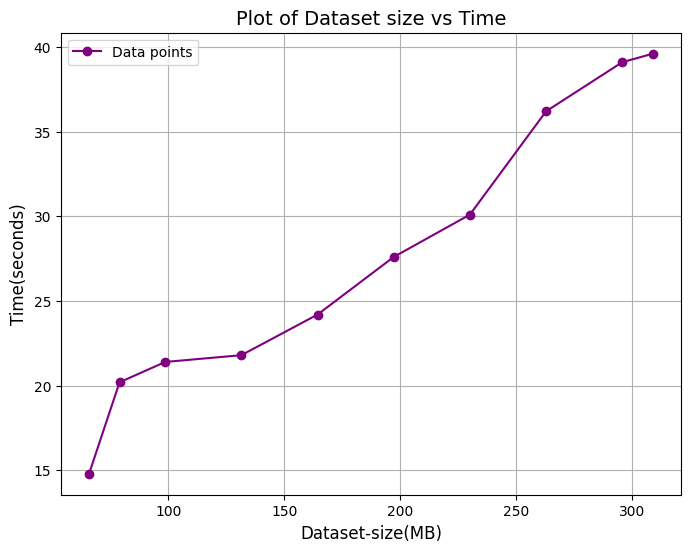

In [10]:
import matplotlib.pyplot as plt

# Data from the table
x1 = [65.77,78.924,98.655, 131.54, 164.425 ,197.31, 230.195, 263.08, 295.965 ,309.119]
y1 = [14.8,20.2,21.4,21.8,24.2,27.6,30.1,36.2,39.1,39.6]

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, marker='o', color='purple', label='Data points')

# Add labels and title
plt.xlabel('Dataset-size(MB)', fontsize=12)
plt.ylabel('Time(seconds)', fontsize=12)
plt.title('Plot of Dataset size vs Time', fontsize=14)
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

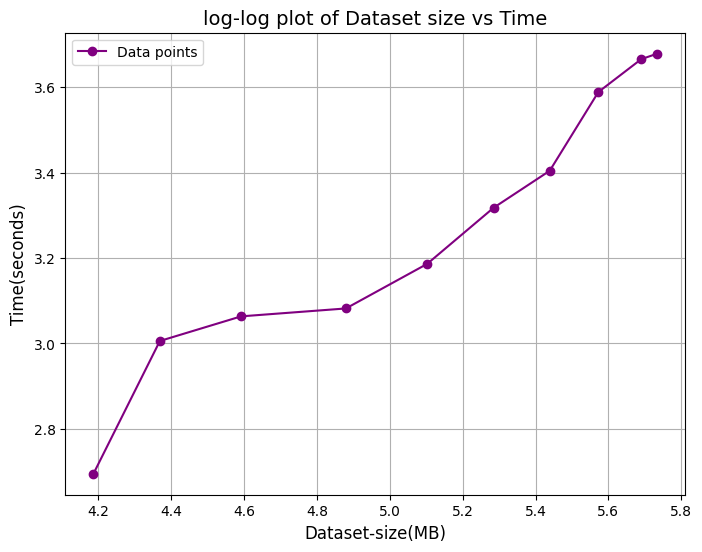

In [11]:
import matplotlib.pyplot as plt
import numpy as np
# Data from the table
x1 = [65.77,78.924,98.655, 131.54, 164.425 ,197.31, 230.195, 263.08, 295.965 ,309.119]
y1 = [14.8,20.2,21.4,21.8,24.2,27.6,30.1,36.2,39.1,39.6]

log_x1=np.log(x1)
log_y1=np.log(y1)
# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(log_x1, log_y1, marker='o', color='purple', label='Data points')

# Add labels and title
plt.xlabel('Dataset-size(MB)', fontsize=12)
plt.ylabel('Time(seconds)', fontsize=12)
plt.title('log-log plot of Dataset size vs Time', fontsize=14)
plt.legend()

# Show the plot
plt.grid(True)
plt.show()